**1. Import Libraries**

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
import warnings
warnings.filterwarnings("ignore")

**2.Load Dataset**

In [2]:
# Load datasets
train_df = pd.read_csv("cargo_acceptance_rejection_train.csv")
val_df = pd.read_csv("cargo_acceptance_rejection_val.csv")
test_df = pd.read_csv("cargo_acceptance_rejection_test.csv")
pd.set_option('display.max_columns', None)
train_df

,record_id,timestamp,airline,SHC,origin,destination,packaging_condition,packaging_seal_status,shipper_company_name,consignee_name,shipper_type,documentation_status,security_screening_status,xray_scan_result,shipment_priority,weather_condition,cargo_weight_kg,damage_history_count,compliance_violation_count,inspection_duration_minutes,shipper_reliability_score,acceptance_rejection_flag
0,1,2023-10-01 00:00:00,Lufthansa,DGR,HAM,JED,Damaged,Intact,DB Schenker,Gulf Fresh Foods,Agent,Complete,Pending,Clear,Normal,Clear,48318,13,8,122,47,0
1,2,2023-10-01 01:00:00,Air India,PER,DXB,JED,Average,Intact,FedEx,Al Jazeera Trading,Agent,Missing,Cleared,Clear,VIP,Clear,2616,2,11,135,93,0
2,3,2023-10-01 02:00:00,Emirates,AVI,HAM,JED,Good,Intact,DHL,Jeddah Electronics,Retail,Pending,Cleared,Suspicious,Express,Fog,20522,9,8,16,70,1
3,4,2023-10-01 03:00:00,Lufthansa,PER,MAA,JED,Average,Tampered,DB Schenker,Arabian Medical Supply,Corporate,Pending,Pending,Manual Review Required,Express,Fog,34711,11,14,174,51,1
4,5,2023-10-01 04:00:00,Lufthansa,VAL,OSL,JED,Good,Intact,Maersk,Gulf Fresh Foods,Corporate,Complete,Cleared,Clear,VIP,Storm,34031,11,4,104,71,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15394,15395,2025-07-03 10:00:00,Qatar,COL,DXB,JED,Average,Tampered,Maersk,Jeddah Electronics,Corporate,Complete,Cleared,Clear,Express,Rain,1244,1,13,176,49,0
15395,15396,2025-07-03 11:00:00,Air India,PER,JFK,JED,Good,Broken,Maersk,Jeddah Electronics,Agent,Missing,Manual Inspection Required,Clear,VIP,Storm,16464,3,9,48,42,1
15396,15397,2025-07-03 12:00:00,Air India,DGR,JFK,JED,Damaged,Intact,FedEx,Jeddah Electronics,Retail,Complete,Failed,Clear,Express,Fog,47683,8,4,110,73,0
15397,15398,2025-07-03 13:00:00,Emirates,COL,MAA,JED,Good,Tampered,Amazon Logistics,Gulf Fresh Foods,Corporate,Complete,Pending,Clear,Express,Storm,9142,0,14,11,93,0


In [3]:
def assign_security_status(xray_result):

    if xray_result == "Suspicious":
        return random.choice([
            "Pending",
            "Manual Inspection Required"
        ])

    elif xray_result == "Restricted Item Detected":
        return "Failed"

    elif xray_result == "Manual Review Required":
        return "Manual Inspection Required"

    elif xray_result == "Clear":
        return random.choice([
            "Cleared",
            "Pending"
        ])

    else:
        return "Pending"


# Apply logic to dataset
train_df["security_screening_status"] = train_df["xray_scan_result"].apply(assign_security_status)
val_df["security_screening_status"] = val_df["xray_scan_result"].apply(assign_security_status)
test_df["security_screening_status"] = test_df["xray_scan_result"].apply(assign_security_status)

**Realistic Security Workflow Mapping**

Added business-rule-based logic between `xray_scan_result` and `security_screening_status` to maintain realistic cargo security screening behavior.  
This ensures that suspicious or restricted X-ray findings cannot incorrectly receive a cleared security status.  
The enhancement improves operational consistency, data quality, and machine learning reliability.  
The dataset now better represents real airline cargo acceptance and security inspection processes.

In [4]:
#make a copy of the original dataframe for catboost
train_df_cat=train_df.copy()
val_df_cat=val_df.copy()
test_df_cat=test_df.copy()  

In [5]:
train_df

,record_id,timestamp,airline,SHC,origin,destination,packaging_condition,packaging_seal_status,shipper_company_name,consignee_name,shipper_type,documentation_status,security_screening_status,xray_scan_result,shipment_priority,weather_condition,cargo_weight_kg,damage_history_count,compliance_violation_count,inspection_duration_minutes,shipper_reliability_score,acceptance_rejection_flag
0,1,2023-10-01 00:00:00,Lufthansa,DGR,HAM,JED,Damaged,Intact,DB Schenker,Gulf Fresh Foods,Agent,Complete,Pending,Clear,Normal,Clear,48318,13,8,122,47,0
1,2,2023-10-01 01:00:00,Air India,PER,DXB,JED,Average,Intact,FedEx,Al Jazeera Trading,Agent,Missing,Pending,Clear,VIP,Clear,2616,2,11,135,93,0
2,3,2023-10-01 02:00:00,Emirates,AVI,HAM,JED,Good,Intact,DHL,Jeddah Electronics,Retail,Pending,Manual Inspection Required,Suspicious,Express,Fog,20522,9,8,16,70,1
3,4,2023-10-01 03:00:00,Lufthansa,PER,MAA,JED,Average,Tampered,DB Schenker,Arabian Medical Supply,Corporate,Pending,Manual Inspection Required,Manual Review Required,Express,Fog,34711,11,14,174,51,1
4,5,2023-10-01 04:00:00,Lufthansa,VAL,OSL,JED,Good,Intact,Maersk,Gulf Fresh Foods,Corporate,Complete,Pending,Clear,VIP,Storm,34031,11,4,104,71,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15394,15395,2025-07-03 10:00:00,Qatar,COL,DXB,JED,Average,Tampered,Maersk,Jeddah Electronics,Corporate,Complete,Cleared,Clear,Express,Rain,1244,1,13,176,49,0
15395,15396,2025-07-03 11:00:00,Air India,PER,JFK,JED,Good,Broken,Maersk,Jeddah Electronics,Agent,Missing,Cleared,Clear,VIP,Storm,16464,3,9,48,42,1
15396,15397,2025-07-03 12:00:00,Air India,DGR,JFK,JED,Damaged,Intact,FedEx,Jeddah Electronics,Retail,Complete,Cleared,Clear,Express,Fog,47683,8,4,110,73,0
15397,15398,2025-07-03 13:00:00,Emirates,COL,MAA,JED,Good,Tampered,Amazon Logistics,Gulf Fresh Foods,Corporate,Complete,Cleared,Clear,Express,Storm,9142,0,14,11,93,0


**3.Basic Understanding of Dataset**

3.1 Check null value


In [6]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15399 entries, 0 to 15398
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   record_id                    15399 non-null  int64 
 1   timestamp                    15399 non-null  object
 2   airline                      15399 non-null  object
 3   SHC                          15399 non-null  object
 4   origin                       15399 non-null  object
 5   destination                  15399 non-null  object
 6   packaging_condition          15399 non-null  object
 7   packaging_seal_status        15399 non-null  object
 8   shipper_company_name         15399 non-null  object
 9   consignee_name               15399 non-null  object
 10  shipper_type                 15399 non-null  object
 11  documentation_status         15399 non-null  object
 12  security_screening_status    15399 non-null  object
 13  xray_scan_result             15

record_id                      0
timestamp                      0
airline                        0
SHC                            0
origin                         0
destination                    0
packaging_condition            0
packaging_seal_status          0
shipper_company_name           0
consignee_name                 0
shipper_type                   0
documentation_status           0
security_screening_status      0
xray_scan_result               0
shipment_priority              0
weather_condition              0
cargo_weight_kg                0
damage_history_count           0
compliance_violation_count     0
inspection_duration_minutes    0
shipper_reliability_score      0
acceptance_rejection_flag      0
dtype: int64

3.2 view columns and view disturbution of target

In [7]:
#Columns in the dataset
print(train_df.columns)


# Distribution of target variable
print(" ")
print(train_df["acceptance_rejection_flag"].value_counts())

Index(['record_id', 'timestamp', 'airline', 'SHC', 'origin', 'destination',
       'packaging_condition', 'packaging_seal_status', 'shipper_company_name',
       'consignee_name', 'shipper_type', 'documentation_status',
       'security_screening_status', 'xray_scan_result', 'shipment_priority',
       'weather_condition', 'cargo_weight_kg', 'damage_history_count',
       'compliance_violation_count', 'inspection_duration_minutes',
       'shipper_reliability_score', 'acceptance_rejection_flag'],
      dtype='object')
 
acceptance_rejection_flag
0    13792
1     1607
Name: count, dtype: int64


In [8]:
print(val_df["acceptance_rejection_flag"].value_counts())
print(test_df["acceptance_rejection_flag"].value_counts())

acceptance_rejection_flag
0    2939
1     362
Name: count, dtype: int64
acceptance_rejection_flag
0    2972
1     328
Name: count, dtype: int64


3.3 view unique value in categorical column

In [9]:
#Unique values in categorical columns
print("Unique values in shipment_priority:")
print(train_df["shipment_priority"].unique())
print(" ")

print("Unique values in shipper_type:")
print(train_df["shipper_type"].unique())
print(" ")

print("Unique values in security_screening_status:")
print(train_df["security_screening_status"].unique())
print(" ")

print("Unique values in xray_scan_result:")
print(train_df["xray_scan_result"].unique())
print(" ")

print("Unique values in weather_condition:")
print(train_df["weather_condition"].unique())
print(" ")

Unique values in shipment_priority:
['Normal' 'VIP' 'Express']
 
Unique values in shipper_type:
['Agent' 'Retail' 'Corporate']
 
Unique values in security_screening_status:
['Pending' 'Manual Inspection Required' 'Cleared' 'Failed']
 
Unique values in xray_scan_result:
['Clear' 'Suspicious' 'Manual Review Required' 'Restricted Item Detected']
 
Unique values in weather_condition:
['Clear' 'Fog' 'Storm' 'Rain']
 


In [10]:
print(train_df["airline"].unique())

['Lufthansa' 'Air India' 'Emirates' 'Qatar']


**4. Data Preprocessing**

4.1 EDA

4.1.1 To create percentage each bar 

In [11]:
def add_percentage_labels(ax):
    
    total = sum([p.get_height() for p in ax.patches])

    for p in ax.patches:
        
        height = p.get_height()
        if height == 0:
            continue

        percentage = f'{100 * height / total:.1f}%'

        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

4.1.2 Chart for Acceptance vs Rejection Distribution

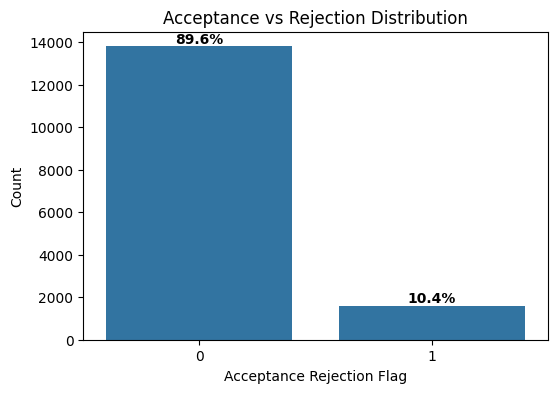

In [12]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='acceptance_rejection_flag',
    data=train_df
)

plt.title("Acceptance vs Rejection Distribution")
plt.xlabel("Acceptance Rejection Flag")
plt.ylabel("Count")

add_percentage_labels(ax)

plt.show()

4.1.3 Chart for Documentation Status vs Rejection

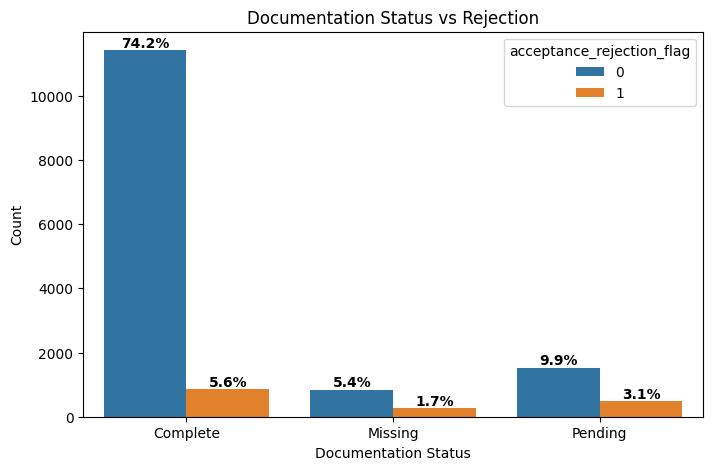

In [13]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='documentation_status',
    hue='acceptance_rejection_flag',
    data=train_df
)

plt.title("Documentation Status vs Rejection")
plt.xlabel("Documentation Status")
plt.ylabel("Count")

add_percentage_labels(ax)

plt.show()


4.1.4 Chart for Packaging Condition vs Rejection

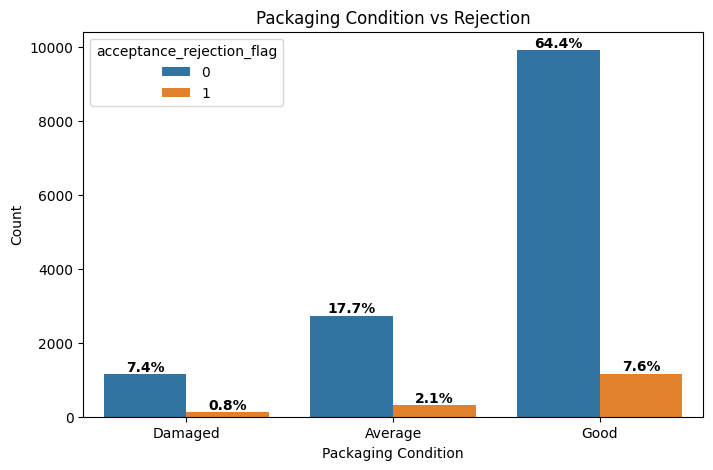

In [14]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='packaging_condition',
    hue='acceptance_rejection_flag',
    data=train_df
)

plt.title("Packaging Condition vs Rejection")
plt.xlabel("Packaging Condition")
plt.ylabel("Count")

add_percentage_labels(ax)

plt.show()

4.1.5 Chart for SHC vs Rejection

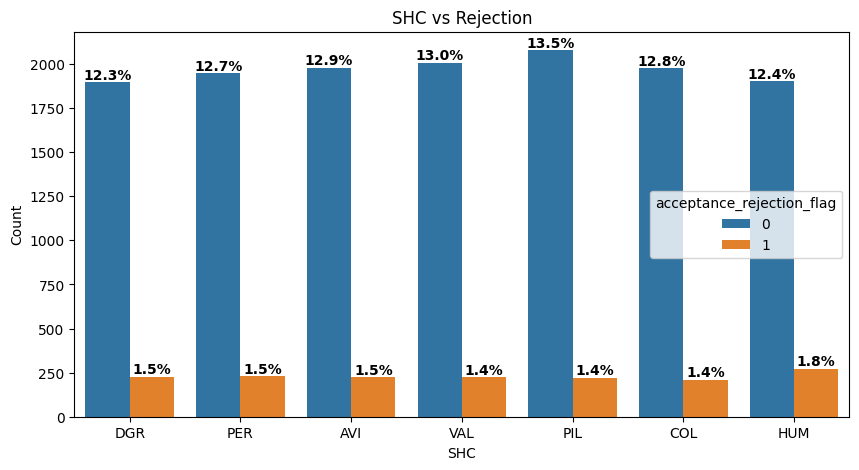

In [15]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x='SHC',
    hue='acceptance_rejection_flag',
    data=train_df
)

plt.title("SHC vs Rejection")
plt.xlabel("SHC")
plt.ylabel("Count")

add_percentage_labels(ax)

plt.show()

4.1.6 Chart for Security Screening Status vs Rejection

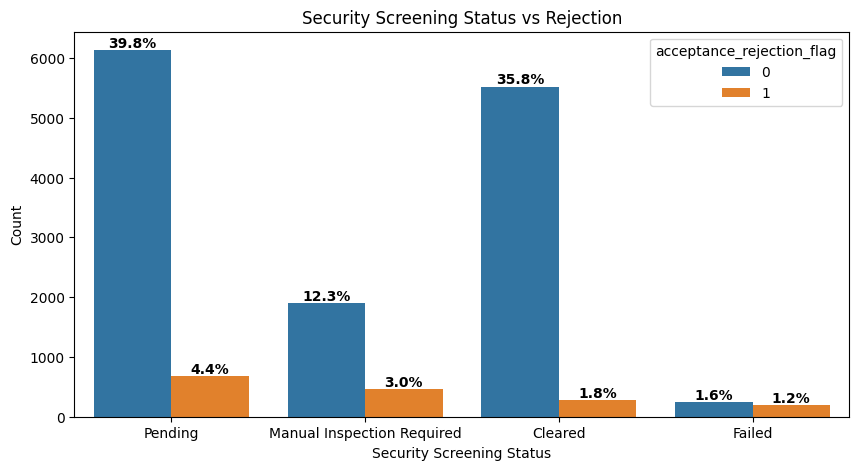

In [16]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    x='security_screening_status',
    hue='acceptance_rejection_flag',
    data=train_df
)

plt.title("Security Screening Status vs Rejection")
plt.xlabel("Security Screening Status")
plt.ylabel("Count")

add_percentage_labels(ax)

plt.show()

**EDA Insights**

- **Acceptance vs Rejection Distribution:**  
  The dataset contains a higher number of accepted shipments compared to rejected shipments, indicating that cargo rejection is a less frequent operational event and the dataset may contain moderate class imbalance.

- **Documentation Status vs Rejection:**  
  Shipments with missing or pending documentation show a significantly higher rejection rate, proving that documentation completeness is one of the most critical factors in cargo acceptance operations.

- **Packaging Condition vs Rejection:**  
  Damaged packaging has a strong association with rejected shipments, while cargo with good packaging condition is mostly accepted, highlighting packaging quality as a major operational risk factor.

- **SHC vs Rejection:**  
  Certain Special Handling Code (SHC) categories such as dangerous or restricted cargo types show comparatively higher rejection rates due to stricter compliance and handling requirements.

- **Security Screening Status vs Rejection:**  
  Shipments with failed or pending security screening statuses exhibit higher rejection probabilities, demonstrating that security validation plays a vital role in cargo acceptance decisions.

4.2 split numerical and categorical column

In [17]:
num_cols_train = train_df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
print(num_cols_train)

cat_cols_train = train_df.select_dtypes(include=['object']).columns
print("Categorical columns:")
print(cat_cols_train)

Numerical columns:
Index(['record_id', 'cargo_weight_kg', 'damage_history_count',
       'compliance_violation_count', 'inspection_duration_minutes',
       'shipper_reliability_score', 'acceptance_rejection_flag'],
      dtype='object')
Categorical columns:
Index(['timestamp', 'airline', 'SHC', 'origin', 'destination',
       'packaging_condition', 'packaging_seal_status', 'shipper_company_name',
       'consignee_name', 'shipper_type', 'documentation_status',
       'security_screening_status', 'xray_scan_result', 'shipment_priority',
       'weather_condition'],
      dtype='object')


In [18]:
# Split numerical and categorical columns for validation and test sets
num_cols_val= val_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols_val = val_df.select_dtypes(include=['object']).columns

num_cols_test = test_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols_test = test_df.select_dtypes(include=['object']).columns

4.3 Encoding the categorical value

In [19]:
# Initialize Label Encoder
le = LabelEncoder()

# Apply encoding on categorical columns
for col in cat_cols_train:
    train_df[col] = le.fit_transform(train_df[col])
    
for col in cat_cols_val:
    val_df[col] = le.fit_transform(val_df[col])
    
for col in cat_cols_test:
    test_df[col] = le.fit_transform(test_df[col])

**why i use Label Encoding instead of One hot Encoding**
Label Encoding was selected instead of One Hot Encoding because the dataset contains multiple categorical features such as airline, SHC, documentation status, and security screening status. Using One Hot Encoding would significantly increase the number of columns and create a high-dimensional sparse dataset.

Most of the machine learning algorithms used in this project, including Decision Tree, Random Forest, XGBoost, and LightGBM, are tree-based models that work efficiently with Label Encoded categorical values, resulting in faster training and simpler preprocessing workflows.

4.4 Split Features and Target Variable

In [20]:
drop_cols = [
    "record_id",
    "timestamp",
    "weather_condition",
    "acceptance_rejection_flag"
]

# Train Dataset
X_train = train_df.drop(drop_cols, axis=1)
y_train = train_df["acceptance_rejection_flag"]
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)


# Validation Dataset
X_val = val_df.drop(drop_cols, axis=1)
y_val = val_df["acceptance_rejection_flag"]
print("X_val Shape:", X_val.shape)
print("y_val Shape:", y_val.shape)


# Test Dataset
X_test = test_df.drop(drop_cols, axis=1)
y_test = test_df["acceptance_rejection_flag"]
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (15399, 18)
y_train Shape: (15399,)
X_val Shape: (3301, 18)
y_val Shape: (3301,)
X_test Shape: (3300, 18)
y_test Shape: (3300,)


4.5 Standard Scaler 

In [21]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale train data
X_train_scaled = scaler.fit_transform(X_train)

# Scale validation data
X_val_scaled = scaler.transform(X_val)

# Scale test data
X_test_scaled = scaler.transform(X_test)

**Why we use Standard Scaler**

StandardScaler was applied to normalize numerical feature values by transforming them into a standard scale with mean 0 and standard deviation 1. This helps machine learning algorithms process features with different value ranges more effectively.

Feature scaling is especially important for algorithms such as Logistic Regression and K-Nearest Neighbors (KNN), because these models are sensitive to feature magnitude and distance calculations.

**5. Model Building**

5.1 Logistic Regression

In [22]:
# Initialize model
lr_model = LogisticRegression(
    C=10,
    penalty='l2',
    max_iter=500,
    random_state=42
)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Validation prediction
y_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_lr = (y_prob_lr > threshold).astype(int)


print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [23]:
# Accuracy
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)

# Precision
lr_precision = precision_score(y_val, y_val_pred_lr)

# Recall
lr_recall = recall_score(y_val, y_val_pred_lr)

# F1 Score
lr_f1 = f1_score(y_val, y_val_pred_lr)

# Print metrics
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lr))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lr))

Accuracy : 0.9145713420175704
Precision: 0.702020202020202
Recall   : 0.3839779005524862
F1 Score : 0.49642857142857144

Confusion Matrix:

[[2880   59]
 [ 223  139]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      2939
           1       0.70      0.38      0.50       362

    accuracy                           0.91      3301
   macro avg       0.82      0.68      0.72      3301
weighted avg       0.90      0.91      0.90      3301



5.2 Decision Tree

In [24]:
# Initialize model
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Validation prediction
y_prob_dt = dt_model.predict_proba(X_val_scaled)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_dt = (y_prob_dt > threshold).astype(int)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [25]:
# Accuracy
dt_accuracy = accuracy_score(y_val, y_val_pred_dt)

# Precision
dt_precision = precision_score(y_val, y_val_pred_dt)

# Recall
dt_recall = recall_score(y_val, y_val_pred_dt)

# F1 Score
dt_f1 = f1_score(y_val, y_val_pred_dt)

# Print metrics
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_dt))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_dt))

Accuracy : 0.8594365343835202
Precision: 0.3344155844155844
Recall   : 0.2845303867403315
F1 Score : 0.3074626865671642

Confusion Matrix:

[[2734  205]
 [ 259  103]]

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2939
           1       0.33      0.28      0.31       362

    accuracy                           0.86      3301
   macro avg       0.62      0.61      0.61      3301
weighted avg       0.85      0.86      0.85      3301



5.3 Random Forest 

In [26]:
# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=13,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
)

# Train model
rf_model.fit(X_train, y_train)

# Validation prediction
y_prob_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

# Custom threshold
threshold = 0.40

# Apply threshold
y_val_pred_rf = (y_prob_rf > threshold).astype(int)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [27]:
# Accuracy
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)

# Precision
rf_precision = precision_score(y_val, y_val_pred_rf)

# Recall
rf_recall = recall_score(y_val, y_val_pred_rf)

# F1 Score
rf_f1 = f1_score(y_val, y_val_pred_rf)

# Print Metrics
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_rf))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_rf))

Accuracy : 0.8882156922144805
Precision: 0.48638132295719844
Recall   : 0.3453038674033149
F1 Score : 0.40387722132471726

Confusion Matrix:

[[2807  132]
 [ 237  125]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2939
           1       0.49      0.35      0.40       362

    accuracy                           0.89      3301
   macro avg       0.70      0.65      0.67      3301
weighted avg       0.87      0.89      0.88      3301



5.4 K Nearest Neighbor

In [28]:
# Initialize KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='minkowski',
    p=2
)

# Train model
knn_model.fit(X_train_scaled, y_train)

y_prob_knn = knn_model.predict_proba(X_val_scaled)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_knn = (y_prob_knn > threshold).astype(int)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [29]:
# Accuracy
knn_accuracy = accuracy_score(y_val, y_val_pred_knn)

# Precision
knn_precision = precision_score(y_val, y_val_pred_knn)

# Recall
knn_recall = recall_score(y_val, y_val_pred_knn)

# F1 Score
knn_f1 = f1_score(y_val, y_val_pred_knn)

# Print Metrics
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_knn))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_knn))

Accuracy : 0.9148742805210542
Precision: 0.7454545454545455
Recall   : 0.3397790055248619
F1 Score : 0.4667931688804554

Confusion Matrix:

[[2897   42]
 [ 239  123]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.99      0.95      2939
           1       0.75      0.34      0.47       362

    accuracy                           0.91      3301
   macro avg       0.83      0.66      0.71      3301
weighted avg       0.90      0.91      0.90      3301



5.5 XGBoost 

In [30]:
# Tuned XGBoost with imbalance handling
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    scale_pos_weight=8.5,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Custom threshold
threshold = 0.45

# Apply threshold
y_val_pred_xgb = (y_prob_xgb > threshold).astype(int)

print("Tuned XGBoost Model Trained Successfully")

Tuned XGBoost Model Trained Successfully


In [31]:
# Accuracy
xgb_accuracy = accuracy_score(y_val, y_val_pred_xgb)

# Precision
xgb_precision = precision_score(y_val, y_val_pred_xgb)

# Recall
xgb_recall = recall_score(y_val, y_val_pred_xgb)

# F1 Score
xgb_f1 = f1_score(y_val, y_val_pred_xgb)

# Print Metrics
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_xgb))

Accuracy : 0.8994244168433808
Precision: 0.5257731958762887
Recall   : 0.8453038674033149
F1 Score : 0.6483050847457628

Confusion Matrix:

[[2663  276]
 [  56  306]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      2939
           1       0.53      0.85      0.65       362

    accuracy                           0.90      3301
   macro avg       0.75      0.88      0.79      3301
weighted avg       0.93      0.90      0.91      3301



In [32]:
# cm = confusion_matrix(y_val, y_val_pred_xgb)

# # Plot confusion matrix
# plt.figure(figsize=(6,5))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['Accepted', 'Rejected'],
#     yticklabels=['Accepted', 'Rejected']
# )

# plt.title("XGBoost Confusion Matrix")
# plt.xlabel("Predicted Label")
# plt.ylabel("Actual Label")

# plt.show()

5.6 LightGBM

In [33]:
# Initialize model
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42
)
# Train model
lgbm_model.fit(X_train, y_train)

# Predict probabilities
y_prob_lgbm = lgbm_model.predict_proba(X_val)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_lgbm = (y_prob_lgbm > threshold).astype(int)


print("LightGBM Model Trained Successfully")

[LightGBM] [Info] Number of positive: 1607, number of negative: 13792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000862 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 15399, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [34]:
# Accuracy
lgbm_accuracy = accuracy_score(y_val, y_val_pred_lgbm)

# Precision
lgbm_precision = precision_score(y_val, y_val_pred_lgbm)

# Recall
lgbm_recall = recall_score(y_val, y_val_pred_lgbm)

# F1 Score
lgbm_f1 = f1_score(y_val, y_val_pred_lgbm)

# Print Metrics
print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lgbm))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lgbm))

Accuracy : 0.9042714328991215
Precision: 0.542910447761194
Recall   : 0.8038674033149171
F1 Score : 0.6481069042316259

Confusion Matrix:

[[2694  245]
 [  71  291]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      2939
           1       0.54      0.80      0.65       362

    accuracy                           0.90      3301
   macro avg       0.76      0.86      0.80      3301
weighted avg       0.93      0.90      0.91      3301



In [35]:
# cm = confusion_matrix(y_val, y_val_pred_lgbm)

# # Plot confusion matrix
# plt.figure(figsize=(6,5))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=['Accepted', 'Rejected'],
#     yticklabels=['Accepted', 'Rejected']
# )

# plt.title("LightGBM Confusion Matrix")
# plt.xlabel("Predicted Label")
# plt.ylabel("Actual Label")

# plt.show()

5.7 Catboost

In [36]:
# Train Dataset
X_train_cat = train_df_cat.drop(
    ['record_id', 'timestamp', 'acceptance_rejection_flag', 'weather_condition','inspection_duration_minutes'],
    axis=1
)

y_train_cat = train_df_cat['acceptance_rejection_flag']


# Validation Dataset
X_val_cat = val_df_cat.drop(
    ['record_id', 'timestamp', 'acceptance_rejection_flag','weather_condition','inspection_duration_minutes'],
    axis=1
)

y_val_cat = val_df_cat['acceptance_rejection_flag']

# Automatically detect categorical columns
cat_features = X_train_cat.select_dtypes(include=['object']).columns.tolist()

print(cat_features)

for col in cat_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col] = X_val_cat[col].astype(str)


['airline', 'SHC', 'origin', 'destination', 'packaging_condition', 'packaging_seal_status', 'shipper_company_name', 'consignee_name', 'shipper_type', 'documentation_status', 'security_screening_status', 'xray_scan_result', 'shipment_priority']


In [37]:
cat_model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.02,
    depth=8,
    l2_leaf_reg=7,
    border_count=254,
    random_strength=2,
    bagging_temperature=2,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1, 8.5],
    random_seed=42,
    verbose=0
)

# Train model
cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features
)

print("Final Tuned CatBoost Model Trained Successfully")

Final Tuned CatBoost Model Trained Successfully


In [38]:
# Validation prediction
y_prob_cat = cat_model.predict_proba(X_val_cat)[:, 1]

# Custom threshold
threshold = 0.60

# Apply threshold
y_val_pred_cat = (y_prob_cat > threshold).astype(int)


In [39]:
# Accuracy
cat_accuracy = accuracy_score(y_val_cat, y_val_pred_cat)

# Precision
cat_precision = precision_score(y_val_cat, y_val_pred_cat)

# Recall
cat_recall = recall_score(y_val_cat, y_val_pred_cat)

# F1 Score
cat_f1 = f1_score(y_val_cat, y_val_pred_cat)

# Print Metrics
print("Accuracy :", cat_accuracy)
print("Precision:", cat_precision)
print("Recall   :", cat_recall)
print("F1 Score :", cat_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val_cat, y_val_pred_cat))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val_cat, y_val_pred_cat))

Accuracy : 0.9045743714026053
Precision: 0.5417406749555951
Recall   : 0.8425414364640884
F1 Score : 0.6594594594594595

Confusion Matrix:

[[2681  258]
 [  57  305]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      2939
           1       0.54      0.84      0.66       362

    accuracy                           0.90      3301
   macro avg       0.76      0.88      0.80      3301
weighted avg       0.93      0.90      0.91      3301



**6. Compare the models**


In [40]:
import pandas as pd

# Create comparison table
model_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],

    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy
    ],

    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision,
        knn_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision
    ],

    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall,
        knn_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall
    ],

    'F1 Score': [
        lr_f1,
        dt_f1,
        rf_f1,
        knn_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1
    ]
})

# F1-score-wise ranking
f1_rank = model_results.sort_values(
    by='F1 Score',
    ascending=False)
print("F1-score-wise Model Ranking:")
print(f1_rank)


# Recall-wise ranking
recall_rank = model_results.sort_values(
    by='Recall',
    ascending=False)
print("\nRecall-wise Model Ranking:")
print(recall_rank)


# Precision-wise ranking
precision_rank = model_results.sort_values(
    by='Precision',
    ascending=False)
print("\nPrecision-wise Model Ranking:")
print(precision_rank)

F1-score-wise Model Ranking:
                 Model  Accuracy  Precision    Recall  F1 Score
6             CatBoost  0.904574   0.541741  0.842541  0.659459
4              XGBoost  0.899424   0.525773  0.845304  0.648305
5             LightGBM  0.904271   0.542910  0.803867  0.648107
0  Logistic Regression  0.914571   0.702020  0.383978  0.496429
3                  KNN  0.914874   0.745455  0.339779  0.466793
2        Random Forest  0.888216   0.486381  0.345304  0.403877
1        Decision Tree  0.859437   0.334416  0.284530  0.307463

Recall-wise Model Ranking:
                 Model  Accuracy  Precision    Recall  F1 Score
4              XGBoost  0.899424   0.525773  0.845304  0.648305
6             CatBoost  0.904574   0.541741  0.842541  0.659459
5             LightGBM  0.904271   0.542910  0.803867  0.648107
0  Logistic Regression  0.914571   0.702020  0.383978  0.496429
2        Random Forest  0.888216   0.486381  0.345304  0.403877
3                  KNN  0.914874   0.745455  0.

**Model Comparison Insights**

- CatBoost achieved the highest F1-score and recall among all evaluated models, indicating the best overall balance between identifying rejected shipments and maintaining stable classification performance.

- XGBoost and LightGBM also delivered strong performance with high recall and competitive F1-scores, confirming that boosting-based algorithms are highly effective for operational cargo rejection prediction tasks.

- KNN achieved the highest precision score, meaning it generated fewer false positive rejection predictions; however, its low recall indicates poor detection of actual rejected shipments, making it less suitable for this business problem.

- Logistic Regression provided strong accuracy and reasonable precision but struggled to detect rejected cargo effectively due to its lower recall performance.

- Decision Tree and Random Forest showed comparatively weaker recall and F1-scores, indicating that single-tree and traditional ensemble methods were less effective than boosting models for capturing complex cargo rejection patterns.

- Based on overall model comparison, CatBoost was selected as the final model because it demonstrated the strongest balance between recall, F1-score, and operational risk detection capability on both validation and test datasets.

**7. Test the model**


In [41]:
# Test Dataset
X_test_cat = test_df_cat.drop(['record_id', 'timestamp', 'acceptance_rejection_flag','weather_condition','inspection_duration_minutes'],axis=1)
y_test_cat = test_df_cat['acceptance_rejection_flag']

for col in cat_features:
    X_test_cat[col] = X_test_cat[col].astype(str)


In [42]:
y_prob_cat = cat_model.predict_proba(X_test_cat)[:, 1]

# Custom threshold
threshold = 0.60

# Apply threshold
y_test_pred_cat = (y_prob_cat > threshold).astype(int)

In [43]:
# Accuracy
accuracy = accuracy_score(y_test_cat, y_test_pred_cat)

# Precision
precision = precision_score(y_test_cat, y_test_pred_cat)

# Recall
recall = recall_score(y_test_cat, y_test_pred_cat)

# F1 Score
f1 = f1_score(y_test_cat, y_test_pred_cat)

# Print metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_cat, y_test_pred_cat))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_cat, y_test_pred_cat))

Accuracy : 0.8975757575757576
Precision: 0.4906015037593985
Recall   : 0.7957317073170732
F1 Score : 0.6069767441860465

Confusion Matrix:

[[2701  271]
 [  67  261]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      2972
           1       0.49      0.80      0.61       328

    accuracy                           0.90      3300
   macro avg       0.73      0.85      0.77      3300
weighted avg       0.93      0.90      0.91      3300



8. Check Feature Importance 

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train_cat.columns,
    'Importance': cat_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                       Feature  Importance
11            xray_scan_result   18.419162
5        packaging_seal_status   18.014237
15  compliance_violation_count   15.975579
16   shipper_reliability_score   15.850295
9         documentation_status   11.834815
14        damage_history_count    8.160871
13             cargo_weight_kg    3.003486
10   security_screening_status    2.466577
4          packaging_condition    1.516246
7               consignee_name    0.992218
1                          SHC    0.898191
12           shipment_priority    0.701358
2                       origin    0.697541
8                 shipper_type    0.580016
0                      airline    0.465129
6         shipper_company_name    0.424279
3                  destination    0.000000


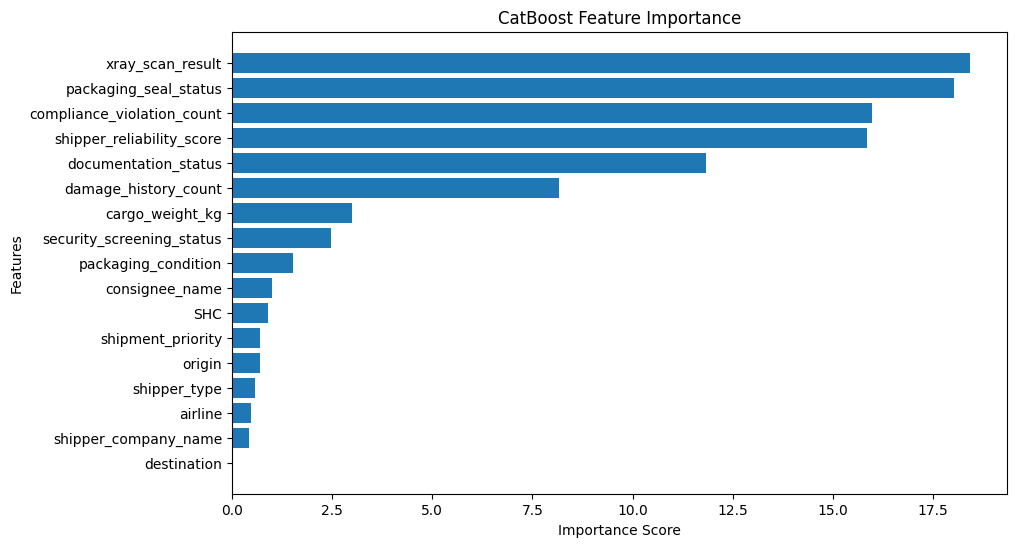

In [45]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

**Feature Importance Insights**

- Packaging seal status was identified as the most influential feature in the prediction process, indicating that cargo seal integrity plays a critical role in acceptance and rejection decisions.

- X-ray scan result and compliance violation count showed high importance scores, demonstrating that security validation and regulatory compliance are major operational factors affecting cargo rejection risk.

- Shipper reliability score and documentation status significantly influenced model predictions, highlighting the importance of shipper trustworthiness and proper documentation during cargo acceptance operations.

- Operational features such as damage history count, inspection duration minutes, and cargo weight also contributed to prediction performance, indicating that shipment handling history and inspection complexity impact rejection probability.

- Features such as destination, weather condition, and consignee details showed relatively lower importance, suggesting they have less direct influence on cargo rejection decisions compared to compliance and security-related factors.

**9. Save the model**

In [46]:
import joblib

# Save CatBoost model
joblib.dump(cat_model, "cargo_rejection_catboost_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


**Why CatBoost Was Selected as the Final Model**

- CatBoost achieved the best balance between recall and F1-score compared to all other evaluated models.

- The model successfully detected 306 rejected cargo shipments while missing only 56 risky shipments, making it highly effective for operational risk detection.

- CatBoost handled categorical logistics and operational features efficiently without requiring complex preprocessing techniques.

- The model showed stable and reliable performance on both validation and test datasets with minimal overfitting.
